<a href="https://colab.research.google.com/github/Anitha20402/pg_project/blob/main/Ai_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
np.save("/content/drive/MyDrive/brain_tumor_data.npy", data)
np.save("/content/drive/MyDrive/brain_tumor_labels.npy", labels)

In [ ]:
!ls "/content/drive/MyDrive/covid_pneumonia"

Data


In [ ]:
# Train & Test paths
train_path = "/content/drive/MyDrive/covid_pneumonia/Data/train"
test_path  = "/content/drive/MyDrive/covid_pneumonia/Data/test"

# Categories (subfolders)
categories = ["COVID19", "NORMAL", "PNEUMONIA"]

In [ ]:
import os
import cv2
import numpy as np

def load_data(data_path, categories):
    data = []
    labels = []

    for category in categories:
        path = os.path.join(data_path, category)
        class_num = categories.index(category)

        for img_name in os.listdir(path):
            try:
                img_path = os.path.join(path, img_name)
                img = cv2.imread(img_path)
                img = cv2.resize(img, (128,128))
                data.append(img)
                labels.append(class_num)
            except:
                pass

    data = np.array(data)/255.0  # normalize
    labels = np.array(labels)
    return data, labels

In [ ]:
X_train, y_train = load_data(train_path, categories)
X_test, y_test   = load_data(test_path, categories)

In [ ]:
print("Train data:", X_train.shape, y_train.shape)
print("Test data:", X_test.shape, y_test.shape)

Train data: (5144, 128, 128, 3) (5144,)
Test data: (1288, 128, 128, 3) (1288,)


In [ ]:
import os
import cv2
import numpy as np

covid_pneumonia_path = "/content/drive/MyDrive/covid_pneumonia/Data/train"
categories = ["COVID19", "NORMAL", "PNEUMONIA"]

covid_data = []
covid_labels = []

for category in categories:
    path = os.path.join(covid_pneumonia_path, category)
    class_num = categories.index(category)

    for img_name in os.listdir(path):
        try:
            img_path = os.path.join(path, img_name)
            img = cv2.imread(img_path)
            img = cv2.resize(img, (128,128))  # reduce size from 224x224
            covid_data.append(img)
            covid_labels.append(class_num)
        except:
            pass

covid_data = np.array(covid_data)/255.0
covid_labels = np.array(covid_labels)

print("COVID data loaded:", covid_data.shape, covid_labels.shape)

COVID data loaded: (5144, 128, 128, 3) (5144,)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

num_classes = 3  # COVID19, NORMAL, PNEUMONIA

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',  # integer labels
              metrics=['accuracy'])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
num_classes = 3  # 3 classes

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')  # 3 units
])

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    "/content/drive/MyDrive/covid_pneumonia/Data/train",  # train folder
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',  # automatically one-hot encode 3 classes
    subset='training'
)

validation_generator = datagen.flow_from_directory(
    "/content/drive/MyDrive/covid_pneumonia/Data/train",  # train folder
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 4116 images belonging to 3 classes.
Found 1028 images belonging to 3 classes.


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # because labels are one-hot
    metrics=['accuracy']
)

In [ ]:
Dense(3, activation='softmax')  # 3 units for 3 classes

<Dense name=dense_6, built=False>

In [ ]:
print(train_generator.num_classes)  # should print 3
print(validation_generator.num_classes)  # should print 3
print(model.output_shape)  # should be (None, 3)

3
3
(None, 3)


In [ ]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 252s 2s/step - accuracy: 0.7099 - loss: 0.6860 - val_accuracy: 0.9027 - val_loss: 0.2687
Epoch 2/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 230s 2s/step - accuracy: 0.9144 - loss: 0.2426 - val_accuracy: 0.9290 - val_loss: 0.1947
Epoch 3/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 234s 2s/step - accuracy: 0.9130 - loss: 0.2237 - val_accuracy: 0.9193 - val_loss: 0.1986
Epoch 4/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step - accuracy: 0.9384 - loss: 0.1882 - val_accuracy: 0.9426 - val_loss: 0.1505
Epoch 5/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 228s 2s/step - accuracy: 0.9457 - loss: 0.1445 - val_accuracy: 0.9562 - val_loss: 0.1348
Epoch 6/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 234s 2s/step - accuracy: 0.9396 - loss: 0.1618 - val_accuracy: 0.9407 - val_loss: 0.1671
Epoch 7/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 221s 2s/step - accuracy: 0.9488 - loss: 0.1407 - val_accuracy: 0.9572 - val_loss: 0.1431
Epoch 8/10
129/129 ━━━━━━━━━━━━━━━━━━━━ 227s 2s/step - accuracy: 0.9534 - loss: 0.1217 - val_accu

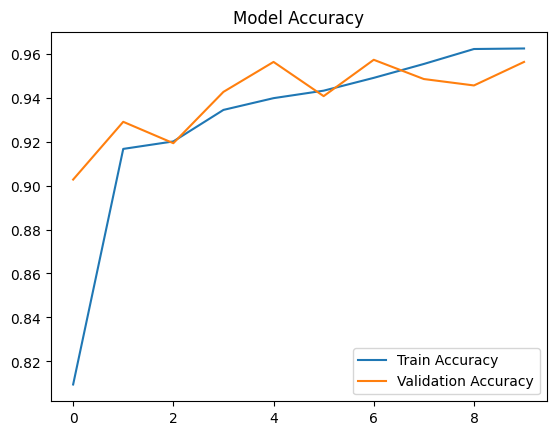

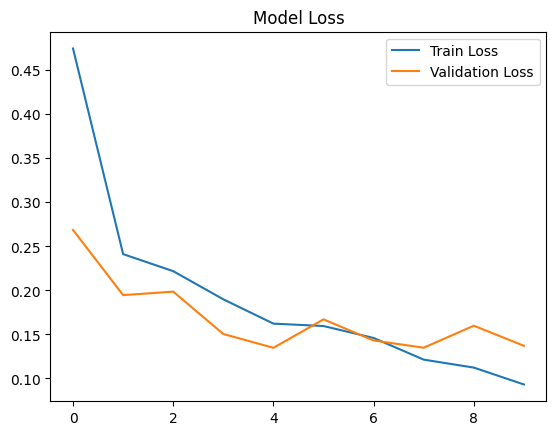

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")
plt.show()

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = "/content/drive/MyDrive/covid_pneumonia/Data/test/COVID19/COVID19(460).jpg"  # CHANGE to your image name

img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

class_names = list(train_generator.class_indices.keys())
predicted_class = class_names[np.argmax(prediction)]

print("Predicted Disease:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
Predicted Disease: COVID19


In [ ]:
model.save("covid_pneumonia_model.h5")

In [ ]:
!pip install streamlit pyngrok tensorflow pillow

In [ ]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

# Load model
model = tf.keras.models.load_model("covid_pneumonia_model.h5")

class_names = ['COVID19', 'NORMAL', 'PNEUMONIA']

st.title("🩺  Disease Prediction")

uploaded_file = st.file_uploader("Upload Chest X-ray Image", type=["jpg","png","jpeg"])

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="Uploaded X-ray", width=400)

    img = image.resize((128,128))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    result = class_names[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    st.success(f"Prediction: {result}")
    st.info(f"Confidence: {confidence:.2f}%")

Overwriting app.py


ngrok token setup (ONCE)
https://dashboard.ngrok.com/signup
Login → Your Authtoken copy pannu
Colab-la paste pannu:
Copy code
Python
from pyngrok import ngrok
ngrok.set_auth_token("PASTE_YOUR_NGROK_TOKEN_HERE")

In [ ]:
from pyngrok import ngrok
ngrok.set_auth_token("37CBngUkZ8qBRwqcHbFrjoDet8N_27w7UTEBrF5yjyEq1Puoa")

In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
public_url = ngrok.connect(8501)
public_url

<NgrokTunnel: "https://nonelementary-wrongly-leonie.ngrok-free.dev" -> "http://localhost:8501">

In [ ]:
model.save("/content/drive/MyDrive/model.keras")

In [ ]:
import pandas as pd
pd.DataFrame(history.history).to_csv("/content/drive/MyDrive/training_history.csv", index=False)

In [ ]:
from tensorflow.keras.models import load_model
model = load_model("/content/drive/MyDrive/model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
import pandas as pd
history_df = pd.read_csv("/content/drive/MyDrive/training_history.csv")

In [ ]:
public_url = ngrok.connect(8501)
public_url

<NgrokTunnel: "https://nonelementary-wrongly-leonie.ngrok-free.dev" -> "http://localhost:8501">